<a href="https://colab.research.google.com/github/celiablanco/YSPLanguageComplexity2026/blob/divya-work-part-3/sourcelang%26round_trip_translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q deep-translator wikipedia-api python-Levenshtein scikit-learn tqdm

In [4]:
import re, time, random, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import Levenshtein
from deep_translator import GoogleTranslator
import wikipediaapi
from tqdm.auto import tqdm

random.seed(42)
np.random.seed(42)

Path("translations").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

In [5]:
# Pull ALL supported target languages from Google Translate (deep-translator) — no hardcoding, no repeats needed
ALL_LANGS = GoogleTranslator(source="auto", target="en").get_supported_languages(as_dict=True)
TARGET_LANGS = sorted(set(ALL_LANGS.values()))

SOURCE_LANGS = {"english": "en", "japanese": "ja", "hindi": "hi"}   # add more if needed

print(f"Loaded {len(TARGET_LANGS)} target languages")
print(TARGET_LANGS)

ROUND_TRIP_LANGS = TARGET_LANGS  # test round-trip on the same full set too

ARTICLE_TITLE = "Water"

Loaded 133 target languages
['af', 'ak', 'am', 'ar', 'as', 'ay', 'az', 'be', 'bg', 'bho', 'bm', 'bn', 'bs', 'ca', 'ceb', 'ckb', 'co', 'cs', 'cy', 'da', 'de', 'doi', 'dv', 'ee', 'el', 'en', 'eo', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'fy', 'ga', 'gd', 'gl', 'gn', 'gom', 'gu', 'ha', 'haw', 'hi', 'hmn', 'hr', 'ht', 'hu', 'hy', 'id', 'ig', 'ilo', 'is', 'it', 'iw', 'ja', 'jw', 'ka', 'kk', 'km', 'kn', 'ko', 'kri', 'ku', 'ky', 'la', 'lb', 'lg', 'ln', 'lo', 'lt', 'lus', 'lv', 'mai', 'mg', 'mi', 'mk', 'ml', 'mn', 'mni-Mtei', 'mr', 'ms', 'mt', 'my', 'ne', 'nl', 'no', 'nso', 'ny', 'om', 'or', 'pa', 'pl', 'ps', 'pt', 'qu', 'ro', 'ru', 'rw', 'sa', 'sd', 'si', 'sk', 'sl', 'sm', 'sn', 'so', 'sq', 'sr', 'st', 'su', 'sv', 'sw', 'ta', 'te', 'tg', 'th', 'ti', 'tk', 'tl', 'tr', 'ts', 'tt', 'ug', 'uk', 'ur', 'uz', 'vi', 'xh', 'yi', 'yo', 'zh-CN', 'zh-TW', 'zu']


In [6]:
def translate_text(text, source, target, max_retries=4):
    for attempt in range(1, max_retries + 1):
        try:
            translator = GoogleTranslator(source=source, target=target)
            if len(text) <= 4500:
                return translator.translate(text)
            chunks, cur = [], ""
            for sent in re.split(r'(?<=[.!?])\s+', text):
                if len(cur) + len(sent) < 4500:
                    cur += sent + " "
                else:
                    chunks.append(cur); cur = sent + " "
            if cur:
                chunks.append(cur)
            return " ".join(translator.translate(c) or "" for c in chunks)
        except Exception as e:
            last_err = e
            time.sleep(1.5 * attempt)
    print(f"[FAILED] {source}->{target}: {last_err}")
    return None

def cached_translate(text, source, target, out_path: Path):
    if out_path.exists():
        return out_path.read_text(encoding="utf-8")
    result = translate_text(text, source, target)
    if result is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_path.write_text(result, encoding="utf-8")
    return result

def fetch_wiki_article(lang_code, title=ARTICLE_TITLE):
    cache = Path("translations") / f"_source_{lang_code}.txt"
    if cache.exists():
        return cache.read_text(encoding="utf-8")
    wiki = wikipediaapi.Wikipedia(user_agent="LangEfficiencyQuickTest/1.0", language=lang_code)
    page = wiki.page(title)
    text = page.text if page.exists() else translate_text(
        wikipediaapi.Wikipedia(user_agent="LangEfficiencyQuickTest/1.0", language="en").page(title).text,
        "en", lang_code)
    cache.write_text(text, encoding="utf-8")
    return text

In [7]:
# 1. Fetch native source articles
source_articles = {name: fetch_wiki_article(code) for name, code in SOURCE_LANGS.items()}
for name, text in source_articles.items():
    print(f"{name}: {len(text):,} characters")

english: 69,192 characters
japanese: 451 characters
hindi: 68,002 characters


In [9]:
# 2. Translate each source into every target language (cached, resumable)
rows = []
for src_name, src_code in SOURCE_LANGS.items():
    out_dir = Path("translations") / f"{src_name}_source"
    for tgt in tqdm(TARGET_LANGS, desc=src_name):
        if tgt == src_code:
            continue
        text = cached_translate(source_articles[src_name], src_code, tgt, out_dir / f"{tgt}.txt")
        if text:
            rows.append({"source": src_name, "target_lang": tgt, "char_count": len(text)})

lengths_df = pd.DataFrame(rows)
lengths_df.to_csv("results/source_language_lengths.csv", index=False)
lengths_df.head()

english:   0%|          | 0/133 [00:00<?, ?it/s]

japanese:   0%|          | 0/133 [00:00<?, ?it/s]

hindi:   0%|          | 0/133 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
    {डिस्प्लेस्टाइल {फ्रैक {dT}dP}}={फ्रैक {टीलेफ्ट(v_{टेक्स्ट{L}}-v_{टेक्स्ट{S}}राइट)}L_{टेक्स्ट{f}}}}}
  

कहाँ 
  
    
      
        
          वी
          
            एल
          
        
      
    
    {डिस्प्लेस्टाइल v_{text{L}}}
  
 और 
  
    
      
        
          वी
          
            एस
          
        
      
    
    {डिस्प्लेस्टाइल v_{text{S}}}
  
 तरल और ठोस चरणों की दाढ़ मात्राएं हैं, और 
  
    
      
        
          एल
          
            च
          
        
      
    
    {डिस्प्लेस्टाइल एल_{टेक्स्ट{एफ}}}
  
 पिघलने की दाढ़ गुप्त ऊष्मा है। अधिकांश पदार्थों में, पिघलने पर आयतन बढ़ जाता है, इसलिए दबाव के साथ पिघलने का तापमान बढ़ जाता है। हालाँकि, चूँकि बर्फ पानी की तुलना में कम घनी होती है, इसलिए पिघलने का तापमान कम हो जाता है। ग्लेशियरों में, बर्फ की पर्याप्त मोटी मात्रा के नीचे दबाव पिघल सकता है, जिसके परिणामस्वरूप सबग्लेशियल झीलें बन सकती हैं। क्लॉसियस-क्लैपेरॉन संबंध क्वथनांक पर भी लागू 

,source,target_lang,char_count
0,english,af,71216
1,english,ak,68561
2,english,am,45543
3,english,ar,62109
4,english,as,63514


               pair  pearson_r  spearman_rho      p_value
english vs japanese   0.912189      0.805524 4.175622e-31


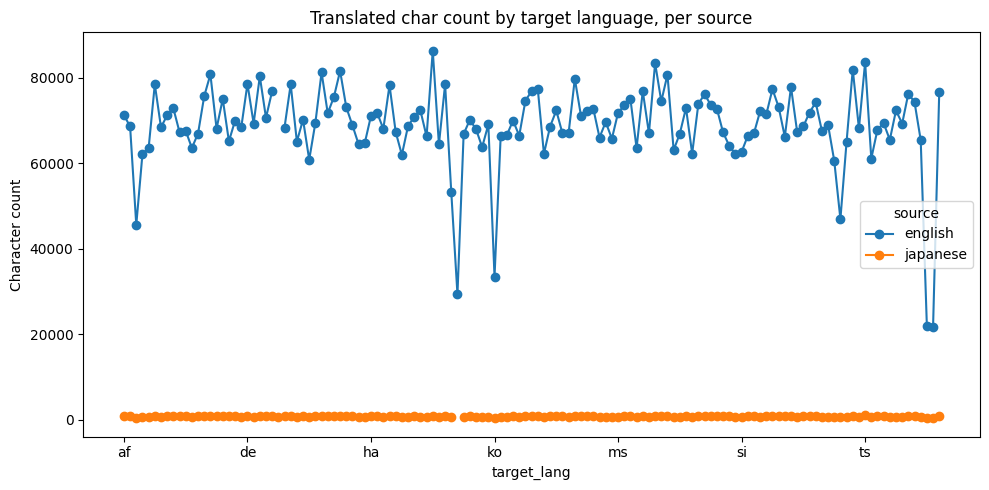

In [10]:
# 3. Correlate length rankings between every pair of source languages
pivot = lengths_df.pivot(index="target_lang", columns="source", values="char_count")

pair_results = []
for a, b in itertools.combinations(pivot.columns, 2):
    merged = pivot[[a, b]].dropna()
    rho, p = stats.spearmanr(merged[a], merged[b])
    r, _ = stats.pearsonr(merged[a], merged[b])
    pair_results.append({"pair": f"{a} vs {b}", "pearson_r": r, "spearman_rho": rho, "p_value": p})

pair_df = pd.DataFrame(pair_results)
print(pair_df.to_string(index=False))

pivot.plot(figsize=(10, 5), marker="o", title="Translated char count by target language, per source")
plt.ylabel("Character count")
plt.tight_layout()
plt.savefig("results/source_language_lengths.png")
plt.show()

In [11]:
# --- CONCLUSION: does source language matter? ---
mean_rho = pair_df["spearman_rho"].mean()
print(f"Mean Spearman rho across source-language pairs: {mean_rho:.3f}\n")

if mean_rho >= 0.7:
    print("CONCLUSION: Source language does NOT matter much.")
    print("-> Translated-length rankings stay largely consistent regardless of which")
    print("   language you start from (rho >= 0.7 = strong agreement).")
elif mean_rho >= 0.4:
    print("CONCLUSION: Source language has a MODERATE effect.")
    print("-> Rankings partly agree but shift depending on the source language.")
else:
    print("CONCLUSION: Source language DOES matter.")
    print("-> Translated-length rankings differ substantially depending on the source")
    print("   language (rho < 0.4 = weak/no agreement).")

Mean Spearman rho across source-language pairs: 0.806

CONCLUSION: Source language does NOT matter much.
-> Translated-length rankings stay largely consistent regardless of which
   language you start from (rho >= 0.7 = strong agreement).


In [12]:
#Experiment B — Does round-trip translation change the text?
english_source = source_articles["english"]

def round_trip_metrics(original, back):
    lev = Levenshtein.distance(original, back)
    norm_edit = lev / max(len(original), len(back), 1)
    tfidf = TfidfVectorizer().fit([original, back])
    vecs = tfidf.transform([original, back])
    cos_sim = cosine_similarity(vecs[0], vecs[1])[0][0]
    return {
        "char_count_diff": len(back) - len(original),
        "levenshtein_distance": lev,
        "normalized_edit_distance": norm_edit,
        "tfidf_cosine_similarity": cos_sim,
    }

rt_rows = []
for tgt in tqdm(ROUND_TRIP_LANGS, desc="Round-trip"):
    fwd = cached_translate(english_source, "en", tgt, Path("results") / f"rt_en_to_{tgt}.txt")
    if fwd is None:
        continue
    back = cached_translate(fwd, tgt, "en", Path("results") / f"rt_{tgt}_to_en.txt")
    if back is None:
        continue
    m = round_trip_metrics(english_source, back)
    m["target_lang"] = tgt
    rt_rows.append(m)

rt_df = pd.DataFrame(rt_rows).sort_values("tfidf_cosine_similarity", ascending=False)
rt_df.to_csv("results/round_trip_metrics.csv", index=False)
rt_df

Round-trip:   0%|          | 0/133 [00:00<?, ?it/s]

[FAILED] am->en: Request exception can happen due to an api connection error. Please check your connection and try again
[FAILED] ar->en: Request exception can happen due to an api connection error. Please check your connection and try again
[FAILED] as->en: পানী হৈছে H2O ৰাসায়নিক সূত্ৰৰ অজৈৱ যৌগ। ই এক স্বচ্ছ, ৰুচিহীন, গন্ধহীন আৰু প্ৰায় ৰংহীন ৰাসায়নিক পদাৰ্থ। ই পৃথিৱীৰ নৈ, হ্ৰদ আৰু মহাসাগৰৰ প্ৰধান গঠন। পানীও সকলো জনাজাত জীৱৰ তৰল পদাৰ্থ, য’ত ই দ্রাৱক হিচাপে কাম কৰে। পানী মেৰু অণু হোৱাৰ বাবে ই শক্তিশালী আন্তঃআণৱিক হাইড্ৰজেন বন্ধনৰ সন্মুখীন হয় যিয়ে ইয়াৰ ভৌতিক আৰু ৰাসায়নিক ধৰ্মত এক বৃহৎ অৰিহণা যোগায়। খাদ্য শক্তি প্ৰদান নকৰা বা জৈৱিক অণুপুষ্টিকৰ উপাদান হোৱাৰ পিছতো ই সকলো জনাজাত জীৱনৰ বাবে অতি প্ৰয়োজনীয়। সকলো জীৱতে ইয়াৰ উপস্থিতি, ইয়াৰ ৰাসায়নিক স্থিৰতা, ইয়াৰ বিশ্বব্যাপী প্ৰাচুৰ্য্য আৰু ইয়াৰ সৰু আণৱিক আকাৰৰ তুলনাত ইয়াৰ শক্তিশালী মেৰুত্বৰ বাবে পানীক প্ৰায়ে "সাৰ্বজনীন দ্রাৱক" বুলি কোৱা হয়। পৃথিৱীৰ পৃষ্ঠৰ উষ্ণতা আৰু চাপ পানীৰ ত্ৰিগুণ বিন্দুৰ তুলনামূলকভাৱে ওচৰত থকাৰ বাবে পৃথিৱীত 

,char_count_diff,levenshtein_distance,normalized_edit_distance,tfidf_cosine_similarity,target_lang
14,-52,190,0.002746,1.000000,en
15,-334,5567,0.080457,0.998452,eo
0,-566,6280,0.090762,0.998322,af
59,-1276,8186,0.118308,0.998320,ro
57,-1026,8660,0.125159,0.998253,pt
...,...,...,...,...,...
28,-4728,14453,0.208883,0.993148,hmn
60,-6609,20083,0.290250,0.993145,rw
48,-4801,17715,0.256027,0.992633,mi
63,-5061,17310,0.250173,0.992428,sm


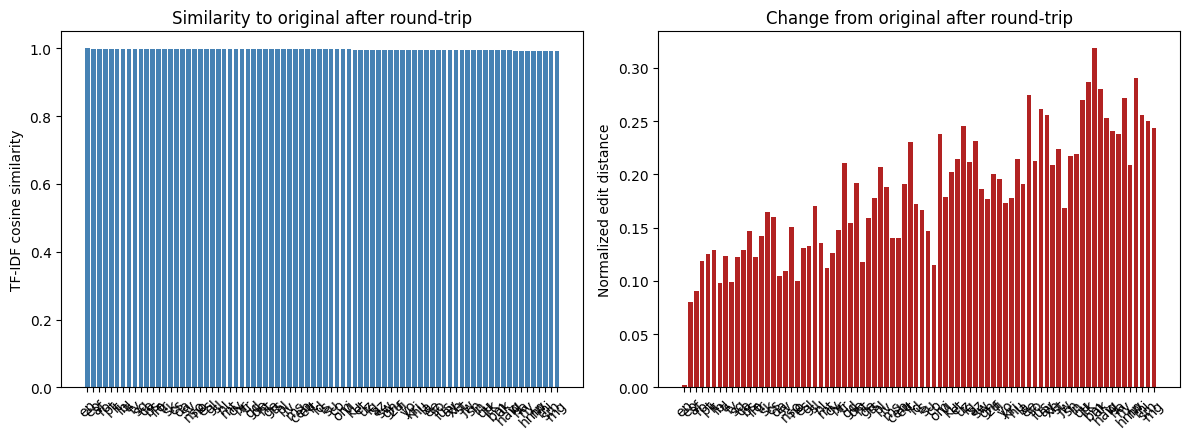

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(rt_df["target_lang"], rt_df["tfidf_cosine_similarity"], color="steelblue")
axes[0].set_title("Similarity to original after round-trip")
axes[0].set_ylabel("TF-IDF cosine similarity")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(rt_df["target_lang"], rt_df["normalized_edit_distance"], color="firebrick")
axes[1].set_title("Change from original after round-trip")
axes[1].set_ylabel("Normalized edit distance")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("results/round_trip_metrics.png")
plt.show()

In [14]:
# --- CONCLUSION: does round-trip translation change the text? ---
mean_sim = rt_df["tfidf_cosine_similarity"].mean()
mean_edit = rt_df["normalized_edit_distance"].mean()
print(f"Mean similarity to original after round-trip: {mean_sim:.3f}")
print(f"Mean normalized edit distance: {mean_edit:.3f}\n")

if mean_sim >= 0.8 and mean_edit <= 0.3:
    print("CONCLUSION: Round-trip translation has LITTLE effect.")
    print("-> Text comes back close to the original (high similarity, low edit distance).")
elif mean_sim >= 0.5:
    print("CONCLUSION: Round-trip translation has a MODERATE effect.")
    print("-> Meaning is roughly preserved but noticeable wording/structure changes occur.")
else:
    print("CONCLUSION: Round-trip translation has a STRONG effect.")
    print("-> The back-translated text differs substantially from the original.")

print("\nBest-preserved languages:")
print(rt_df.head(3)[["target_lang", "tfidf_cosine_similarity", "normalized_edit_distance"]].to_string(index=False))
print("\nWorst-preserved languages:")
print(rt_df.tail(3)[["target_lang", "tfidf_cosine_similarity", "normalized_edit_distance"]].to_string(index=False))

Mean similarity to original after round-trip: 0.996
Mean normalized edit distance: 0.181

CONCLUSION: Round-trip translation has LITTLE effect.
-> Text comes back close to the original (high similarity, low edit distance).

Best-preserved languages:
target_lang  tfidf_cosine_similarity  normalized_edit_distance
         en                 1.000000                  0.002746
         eo                 0.998452                  0.080457
         af                 0.998322                  0.090762

Worst-preserved languages:
target_lang  tfidf_cosine_similarity  normalized_edit_distance
         mi                 0.992633                  0.256027
         sm                 0.992428                  0.250173
         mg                 0.991829                  0.243670


In [19]:
# ====== PASTE YOUR NEW GITHUB TOKEN HERE (make sure you revoked the leaked one first) ======
GITHUB_TOKEN = ""
BRANCH_NAME = "divya-work-part-3"   # your own branch — change if you want a different name
# ==============================================================================================

import os
os.environ["GITHUB_TOKEN"] = GITHUB_TOKEN

REPO_URL = "https://github.com/celiablanco/YSPLanguageComplexity2026.git"
REPO_DIR = "YSPLanguageComplexity2026"

!git config --global user.email "your-github-email@example.com"
!git config --global user.name "Divyashukla-01"

# Clone only if not already cloned this session; otherwise pull latest
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("Repo already cloned — pulling latest")
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}

# Create your own branch off main (or switch to it if it already exists)
!git checkout main
!git pull
!git checkout -b {BRANCH_NAME} 2>/dev/null || git checkout {BRANCH_NAME}

%cd ..

# Copy your results in
!cp -r results {REPO_DIR}/ 2>/dev/null || echo "results/ not found — check the folder name/path"
!cp -r translations {REPO_DIR}/ 2>/dev/null || echo "translations/ not found — skipping (optional anyway)"
!cp quick_two_experiments.ipynb {REPO_DIR}/ 2>/dev/null || echo "notebook not found on disk — download it via Colab File > Download > .ipynb first, then upload and rerun this line"

%cd {REPO_DIR}
!git add .
!git commit -m "Add source-language and round-trip translation experiments with results"
!git push https://$GITHUB_TOKEN@github.com/celiablanco/YSPLanguageComplexity2026.git {BRANCH_NAME}
%cd ..

Cloning into 'YSPLanguageComplexity2026'...
remote: Enumerating objects: 835, done.
remote: Counting objects: 100% (835/835), done.
remote: Compressing objects: 100% (799/799), done.
remote: Total 835 (delta 47), reused 803 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (835/835), 23.51 MiB | 9.88 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/YSPLanguageComplexity2026
Already on 'main'
Your branch is up to date with 'origin/main'.
Already up to date.
/content
notebook not found on disk — download it via Colab File > Download > .ipynb first, then upload and rerun this line
/content/YSPLanguageComplexity2026
[divya-work-part-3 6593275] Add source-language and round-trip translation experiments with results
 483 files changed, 71795 insertions(+)
 create mode 100644 results/round_trip_metrics.csv
 create mode 100644 results/round_trip_metrics.png
 create mode 100644 results/rt_af_to_en.txt
 create mode 100644 results/rt_ak_to_en.txt
 create mode 100644 results/rt